In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 6.9 MB/s eta 0:00:00


In [1]:
!nvidia-smi

Fri May  8 13:55:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
!find /content/drive/MyDrive -name "*.zip"

/content/drive/MyDrive/Classroom/COMPUTER NETWORK LAB IMT-2022/2022IMT049.zip
/content/drive/MyDrive/Classroom/MCOM 2022IMT/Appscreeshot.zip
/content/drive/MyDrive/Classroom/MCOM 2022IMT/Adminside.zip
/content/drive/MyDrive/Classroom/MCOM 2022IMT/studentexpoapp.zip
/content/drive/MyDrive/Classroom/BDA-IMT-2022-ITIT-4202/2022IMT049_Task2_BDALab.zip
/content/drive/MyDrive/FIT2022049.zip
/content/drive/MyDrive/2022IMT049.zip
/content/drive/MyDrive/cg question (1).zip
/content/drive/MyDrive/2022IMT049_NLP.zip
/content/drive/MyDrive/drone_detection.zip


In [7]:
import zipfile

zip_path = "/content/drive/MyDrive/drone_detection.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/")

print("Dataset extracted successfully")

Dataset extracted successfully


In [8]:
!ls /content/drone_detection

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [9]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 36.7 MB/s eta 0:00:00


In [10]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/drone_detection/data.yaml",
    epochs=20,
    imgsz=640,
    batch=16,
    device=0,
    project="/content/drive/MyDrive/DRDO_Project",
    name="drdo_aerial_detector"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drone_detection/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7dac89dbab40>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

Prediction code

In [11]:
from ultralytics import YOLO

# Load trained model
model = YOLO(
    "/content/drive/MyDrive/DRDO_Project/drdo_aerial_detector/weights/best.pt"
)

# Run prediction
model.predict(
    source="/content/drone_detection/test/images",
    save=True,
    conf=0.4
)

print("Prediction completed")


image 1/596 /content/drone_detection/test/images/V_AIRPLANE_0011_025_png.rf.1224f43106fb9462c60db7add1b26996.jpg: 640x640 1 AirPlane, 8.4ms
image 2/596 /content/drone_detection/test/images/V_AIRPLANE_0022_001_png.rf.7301f4f135876a95275860daa9d48925.jpg: 640x640 1 AirPlane, 7.9ms
image 3/596 /content/drone_detection/test/images/V_AIRPLANE_0022_100_png.rf.8394f6bce59a4696af0ca4d855b7cbe8.jpg: 640x640 1 AirPlane, 7.2ms
image 4/596 /content/drone_detection/test/images/V_AIRPLANE_0033_059_png.rf.252225cb15fcb95afd30784651d66235.jpg: 640x640 1 AirPlane, 7.2ms
image 5/596 /content/drone_detection/test/images/V_AIRPLANE_0033_199_png.rf.32eaad528543976672925da04a851007.jpg: 640x640 1 AirPlane, 7.2ms
image 6/596 /content/drone_detection/test/images/V_AIRPLANE_0044_183_png.rf.3f9c00c085bfeedc437ccb69b8258f67.jpg: 640x640 1 AirPlane, 7.2ms
image 7/596 /content/drone_detection/test/images/V_AIRPLANE_0044_244_png.rf.938bf35d7cceeabc851a2dac20046bcf.jpg: 640x640 1 AirPlane, 7.2ms
image 8/596 /conten

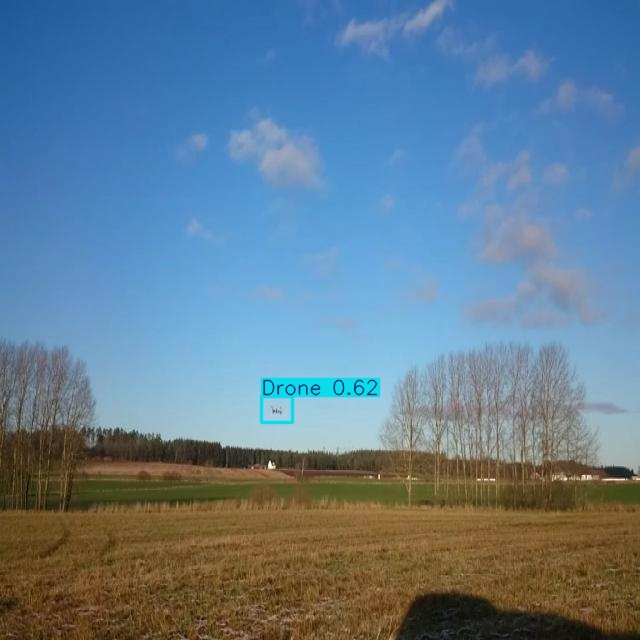

In [23]:
from IPython.display import Image, display
import os

predict_folder = "/content/runs/detect/predict"

images = os.listdir(predict_folder)

display(Image(filename=f"{predict_folder}/{images[10]}"))